**Mobina Vafaei 25120467 - NLP - Best Model: Stacking Classifier**

###**Preproccessing**

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import re, html     # Regular expressions & HTML unescaping
import string      # String constants
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
# Text Normalization & NLP Libraries
import nltk
from nltk.tokenize import word_tokenize, TweetTokenizer     # Text normalization: Tokenization
from nltk import word_tokenize, pos_tag     # Part-of-Speech tagging
from nltk.stem import WordNetLemmatizer     # Text normalization: Lemmatization
from nltk.corpus import wordnet
from nltk.corpus import stopwords     # Remove stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer     # TF-IDF feature extraction

# Download Required NLTK Resources
nltk.download("punkt")     # Tokenizer models
nltk.download("punkt_tab")     # Additional tokenizer tables
nltk.download('stopwords')     # Stopword list
nltk.download('averaged_perceptron_tagger_eng')     # POS tagger
nltk.download('wordnet')     # Lemmatization resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
# Machine Learning Libraries
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import StackingClassifier

# Evaluation Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [4]:
train_path = "/content/train.csv"
df = pd.read_csv(train_path)   # Load the dataset
df.head()     # observe 5 first rows

,id,tweet,label
0,86426,@USER She should ask a few native Americans wh...,UNT
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN
2,16820,Amazon is investigating Chinese employees who ...,NOT
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT


<Axes: xlabel='label', ylabel='count'>

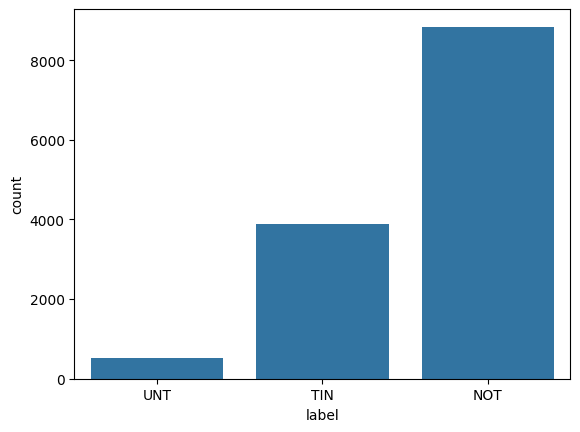

In [5]:
# Summarise class details
sb.countplot(x=df['label'])

In [6]:
print("Shape:", df.shape)
print("\nLabel counts:\n", df["label"].value_counts())

Shape: (13240, 3)

Label counts:
 label
NOT    8840
TIN    3876
UNT     524
Name: count, dtype: int64


In [7]:
df.dropna(inplace=True)
print(f'Number of entries: {len(df)}')

Number of entries: 13240


In [8]:
# Regex normalization
def normalize_profanity(tweet):
    tweet = re.sub(r"\bbull\s*sh\W*t\b", "bullshit", tweet, flags=re.I)
    tweet = re.sub(r"\bsh\W*t\b", "shit", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*ing\b", "fucking", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*s\b", "fucks", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\b", "fuck", tweet, flags=re.I)
    tweet = re.sub(r"\bd\W*mbasses\b", "dumbasses", tweet, flags=re.I)
    tweet = re.sub(r"\bc\W*ck\b", "cock", tweet, flags=re.I)
    return tweet

In [9]:
# convert text to tokens
tokenizer = TweetTokenizer(preserve_case=False,
                    strip_handles=True,
                    reduce_len=True
)
for i in range(5):
    tweet = df["tweet"].iloc[i]
    tokens = tokenizer.tokenize(tweet)
    print("Original:", tweet)
    print("Tokens:", tokens)
    print("-" * 50)

Original: @USER She should ask a few native Americans what their take on this is.
Tokens: ['she', 'should', 'ask', 'a', 'few', 'native', 'americans', 'what', 'their', 'take', 'on', 'this', 'is', '.']
--------------------------------------------------
Original: @USER @USER Go home you’re drunk!!! @USER #MAGA #Trump2020 👊🇺🇸👊 URL
Tokens: ['go', 'home', 'you', '’', 're', 'drunk', '!', '!', '!', '#maga', '#trump2020', '👊', '🇺🇸', '👊', 'url']
--------------------------------------------------
Original: Amazon is investigating Chinese employees who are selling internal data to third-party sellers looking for an edge in the competitive marketplace. URL #Amazon #MAGA #KAG #CHINA #TCOT
Tokens: ['amazon', 'is', 'investigating', 'chinese', 'employees', 'who', 'are', 'selling', 'internal', 'data', 'to', 'third-party', 'sellers', 'looking', 'for', 'an', 'edge', 'in', 'the', 'competitive', 'marketplace', '.', 'url', '#amazon', '#maga', '#kag', '#china', '#tcot']
---------------------------------------

In [10]:
# Merge to tokens back into sentences by adding a space between two tokens.
joined_tokens_list = []
for tweet in df["tweet"]:
    tokens = tokenizer.tokenize(tweet)
    joined_tokens = " ".join(tokens)
    joined_tokens_list.append(joined_tokens)

# add new column to data frame
df["tokenized_tweet"] = joined_tokens_list
df.head()

,id,tweet,label,tokenized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to..."
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...


In [11]:
# Apply POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [12]:
# Lemmatized with WordNet to reduce inflected forms to their base form,
wnl = WordNetLemmatizer()
df["lemmatized_tweet"] = df["tokenized_tweet"].apply(
    lambda tweet_string: " ".join(
        wnl.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in nltk.pos_tag(nltk.word_tokenize(tweet_string))
    )
)
df.head()

,id,tweet,label,tokenized_tweet,lemmatized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...,she should ask a few native american what thei...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...,go home you ’ re drunk ! ! ! # maga # trump202...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...,amazon be investigate chinese employee who be ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to...",someone should'vetaken `` this piece of shit t...
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...,obama want liberal & illegals to move into red...


In [13]:
# get English stopwords
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [14]:
# Define features and labels
X_tweet = df['tweet']
X_tokenized = df['tokenized_tweet']
X_lemmatized = df['lemmatized_tweet']
y = df['label']

In [15]:
# Train / test split
(X_tweet_train, X_tweet_val,
 X_tokenized_train, X_tokenized_val,
 X_lemmatized_train, X_lemmatized_val,
 y_train, y_val) = train_test_split(X_tweet, X_tokenized, X_lemmatized, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
# Sanity check
print("Tweet:", len(X_tweet_train),",", len(X_tweet_val))
print("Tokenized:", len(X_tokenized_train),",", len(X_tokenized_val))
print("Lemmatized:", len(X_lemmatized_train),",", len(X_lemmatized_val))
print("Labels:", len(y_train),",", len(y_val))

Tweet: 9268 , 3972
Tokenized: 9268 , 3972
Lemmatized: 9268 , 3972
Labels: 9268 , 3972


In [17]:
# Evaluation function
def evaluate(actuals, predictions, labels):

    # 1) Accuracy
    accuracy = metrics.accuracy_score(actuals, predictions)
    print(f"Accuracy: {accuracy:.4f}")

    # 2) Precision, Recall, F1 (macro)
    precision = metrics.precision_score(actuals, predictions, average="macro", zero_division=0)
    recall = metrics.recall_score(actuals, predictions, average="macro", zero_division=0)
    f1 = metrics.f1_score(actuals, predictions, average="macro", zero_division=0)

    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")

    # 3) Confusion Matrix
    cm = metrics.confusion_matrix(actuals, predictions, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    # return values
    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm
    }

###**Stacking Classifier**

In [ ]:
# Base models for an ensemble
base_estimators = [

    # LogisticRegression
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42)),

    # Linear SVC
    ("linsvm", LinearSVC(
            C=1.0,     # Regularization strength
            class_weight="balanced",
            random_state=42)),

    # SGDClassifier
    ("sdg", SGDClassifier(
            max_iter=3000,
            class_weight="balanced",
            tol=1e-3,     # Convergence tolerance
            random_state=42,
            alpha=1e-4,     # Regularization strength
            loss="log_loss"))]     # Logistic loss

In [ ]:
# Meta-classifier for Stacking Ensemble
meta_classifier = LogisticRegression(
    C=0.5,
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

In [ ]:
# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    stack_method="auto",
    n_jobs=-1
)

In [ ]:
# Model 1, ngram_range=(1, 1)
stacking_pipeline = Pipeline([
    (
        "CountVec",
        CountVectorizer(lowercase=True, ngram_range=(1, 1))
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.80      0.84      0.82      2652
         TIN       0.57      0.48      0.52      1163
         UNT       0.20      0.24      0.22       157

    accuracy                           0.71      3972
   macro avg       0.52      0.52      0.52      3972
weighted avg       0.71      0.71      0.71      3972

Macro F1: 0.5175004082712533


In [ ]:
# Model 1, ngram_range=(1, 2)
stacking_pipeline1 = Pipeline([
    (
        "CountVec",
        CountVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline1.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline1.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.78      0.86      0.82      2652
         TIN       0.58      0.47      0.52      1163
         UNT       0.21      0.17      0.19       157

    accuracy                           0.72      3972
   macro avg       0.53      0.50      0.51      3972
weighted avg       0.70      0.72      0.71      3972

Macro F1: 0.50847332663123


In [ ]:
# Model 1, ngram_range=(2, 2)
stacking_pipeline2 = Pipeline([
    (
        "CountVec",
        CountVectorizer(
            lowercase=True,
            ngram_range=(2, 2),
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline2.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline2.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.72      0.86      0.78      2652
         TIN       0.47      0.29      0.36      1163
         UNT       0.19      0.10      0.13       157

    accuracy                           0.66      3972
   macro avg       0.46      0.41      0.42      3972
weighted avg       0.62      0.66      0.63      3972

Macro F1: 0.4225568412463334


In [ ]:
# Model 1, ngram_range=(1, 3)
stacking_pipeline3 = Pipeline([
    (
        "CountVec",
        CountVectorizer(
            lowercase=True,
            ngram_range=(1, 3),
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline3.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline3.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.78      0.86      0.82      2652
         TIN       0.59      0.48      0.53      1163
         UNT       0.23      0.14      0.17       157

    accuracy                           0.72      3972
   macro avg       0.53      0.49      0.51      3972
weighted avg       0.70      0.72      0.71      3972

Macro F1: 0.5077969046543521


In [ ]:
# Model 1, ngram_range=(3, 3)
stacking_pipeline4 = Pipeline([
    (
        "CountVec",
        CountVectorizer(
            lowercase=True,
            ngram_range=(3, 3),
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline4.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline4.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.69      0.91      0.78      2652
         TIN       0.46      0.17      0.25      1163
         UNT       0.14      0.04      0.06       157

    accuracy                           0.66      3972
   macro avg       0.43      0.37      0.36      3972
weighted avg       0.60      0.66      0.60      3972

Macro F1: 0.3637822395378046


In [ ]:
# Model 2, ngram_range=(1, 1)
stacking_pipeline2 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline2.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline2.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.80      0.82      0.81      2652
         TIN       0.55      0.50      0.53      1163
         UNT       0.19      0.24      0.21       157

    accuracy                           0.70      3972
   macro avg       0.51      0.52      0.52      3972
weighted avg       0.70      0.70      0.70      3972

Macro F1: 0.515112663783699


In [ ]:
# Model 2, ngram_range=(1, 2)
stacking_pipeline21 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline21.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline21.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.80      0.80      0.80      2652
         TIN       0.53      0.55      0.54      1163
         UNT       0.22      0.20      0.21       157

    accuracy                           0.70      3972
   macro avg       0.52      0.51      0.51      3972
weighted avg       0.70      0.70      0.70      3972

Macro F1: 0.514073357900617


In [ ]:
# Model 2, ngram_range=(2, 2)
stacking_pipeline22 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(2, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline22.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline22.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.73      0.80      0.76      2652
         TIN       0.44      0.36      0.40      1163
         UNT       0.20      0.11      0.14       157

    accuracy                           0.65      3972
   macro avg       0.45      0.42      0.43      3972
weighted avg       0.62      0.65      0.63      3972

Macro F1: 0.4326740405831875


In [ ]:
# Model 2, ngram_range=(1, 3)
stacking_pipeline23 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline23.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline23.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.79      0.80      2652
         TIN       0.52      0.56      0.54      1163
         UNT       0.22      0.18      0.20       157

    accuracy                           0.70      3972
   macro avg       0.52      0.51      0.51      3972
weighted avg       0.70      0.70      0.70      3972

Macro F1: 0.5121410771309223


In [ ]:
# Model 2, ngram_range=(3, 3)
stacking_pipeline24 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(3, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline24.fit(X_tweet_train, y_train)

# Predict
y_pred = stacking_pipeline24.predict(X_tweet_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.69      0.88      0.77      2652
         TIN       0.40      0.17      0.24      1163
         UNT       0.10      0.04      0.06       157

    accuracy                           0.64      3972
   macro avg       0.40      0.37      0.36      3972
weighted avg       0.58      0.64      0.59      3972

Macro F1: 0.3570260326416584


In [ ]:
# Model 3, ngram_range=(1, 1)
stacking_pipeline3 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline3.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline3.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.82      0.81      2652
         TIN       0.55      0.51      0.53      1163
         UNT       0.18      0.23      0.20       157

    accuracy                           0.71      3972
   macro avg       0.51      0.52      0.51      3972
weighted avg       0.71      0.71      0.71      3972

Macro F1: 0.5138508310050488


In [ ]:
# Model 3, ngram_range=(1, 2)
stacking_pipeline31 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline31.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline31.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.82      0.80      0.81      2652
         TIN       0.54      0.56      0.55      1163
         UNT       0.19      0.20      0.19       157

    accuracy                           0.71      3972
   macro avg       0.52      0.52      0.52      3972
weighted avg       0.71      0.71      0.71      3972

Macro F1: 0.5175689821518646


In [ ]:
# Model 3, ngram_range=(2, 2)
stacking_pipeline32 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(2, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline32.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline32.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.72      0.80      0.76      2652
         TIN       0.42      0.36      0.39      1163
         UNT       0.19      0.08      0.12       157

    accuracy                           0.64      3972
   macro avg       0.45      0.41      0.42      3972
weighted avg       0.61      0.64      0.62      3972

Macro F1: 0.42033461209438916


In [ ]:
# Model 3, ngram_range=(1, 3)
stacking_pipeline33 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline33.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline33.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.79      0.80      2652
         TIN       0.52      0.56      0.54      1163
         UNT       0.20      0.21      0.20       157

    accuracy                           0.70      3972
   macro avg       0.51      0.52      0.51      3972
weighted avg       0.70      0.70      0.70      3972

Macro F1: 0.5135737481527337


In [ ]:
# Model 3, ngram_range=(3, 3)
stacking_pipeline34 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(3, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline34.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline34.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.68      0.89      0.77      2652
         TIN       0.39      0.14      0.21      1163
         UNT       0.03      0.01      0.02       157

    accuracy                           0.64      3972
   macro avg       0.37      0.35      0.33      3972
weighted avg       0.57      0.64      0.58      3972

Macro F1: 0.3322812050427059


In [ ]:
# Model 4, ngram_range=(1, 1)
stacking_pipeline4 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline4.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline4.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.82      0.82      2652
         TIN       0.56      0.52      0.54      1163
         UNT       0.22      0.27      0.24       157

    accuracy                           0.71      3972
   macro avg       0.53      0.54      0.53      3972
weighted avg       0.71      0.71      0.71      3972

Macro F1: 0.5323290306746062


In [ ]:
# Model 4, ngram_range=(1, 2)
stacking_pipeline41 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline41.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline41.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.82      0.80      0.81      2652
         TIN       0.53      0.56      0.54      1163
         UNT       0.18      0.19      0.18       157

    accuracy                           0.70      3972
   macro avg       0.51      0.51      0.51      3972
weighted avg       0.71      0.70      0.71      3972

Macro F1: 0.5118538140965809


In [ ]:
# Model 4, ngram_range=(2, 2)
stacking_pipeline42 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(2, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline42.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline42.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.73      0.79      0.76      2652
         TIN       0.45      0.39      0.41      1163
         UNT       0.15      0.10      0.12       157

    accuracy                           0.64      3972
   macro avg       0.44      0.43      0.43      3972
weighted avg       0.63      0.64      0.63      3972

Macro F1: 0.43092603925354217


In [ ]:
# Model 4, ngram_range=(1, 3)
stacking_pipeline43 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline43.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline43.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.82      0.79      0.80      2652
         TIN       0.53      0.58      0.56      1163
         UNT       0.20      0.21      0.20       157

    accuracy                           0.70      3972
   macro avg       0.52      0.53      0.52      3972
weighted avg       0.71      0.70      0.71      3972

Macro F1: 0.5203230057101919


In [ ]:
# Model 4, ngram_range=(3, 3)
stacking_pipeline44 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(3, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline44.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline44.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.68      0.89      0.77      2652
         TIN       0.39      0.15      0.22      1163
         UNT       0.03      0.01      0.02       157

    accuracy                           0.64      3972
   macro avg       0.37      0.35      0.33      3972
weighted avg       0.57      0.64      0.58      3972

Macro F1: 0.3348195896995719


In [ ]:
# Model 5, ngram_range=(1, 1)
stacking_pipeline5 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline5.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline5.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.82      0.81      2652
         TIN       0.55      0.51      0.53      1163
         UNT       0.19      0.23      0.21       157

    accuracy                           0.71      3972
   macro avg       0.52      0.52      0.52      3972
weighted avg       0.71      0.71      0.71      3972

Macro F1: 0.5176065813547368


In [ ]:
# Model 5, ngram_range=(1, 2)
stacking_pipeline51 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline51.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline51.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.81      0.81      2652
         TIN       0.53      0.52      0.53      1163
         UNT       0.22      0.27      0.24       157

    accuracy                           0.70      3972
   macro avg       0.52      0.53      0.52      3972
weighted avg       0.70      0.70      0.70      3972

Macro F1: 0.5233641798804413


In [ ]:
# Model 5, ngram_range=(2, 2)
stacking_pipeline52 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(2, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline52.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline52.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.69      0.87      0.77      2652
         TIN       0.42      0.19      0.26      1163
         UNT       0.09      0.05      0.07       157

    accuracy                           0.64      3972
   macro avg       0.40      0.37      0.37      3972
weighted avg       0.59      0.64      0.59      3972

Macro F1: 0.3660108559680799


In [ ]:
# Model 5, ngram_range=(1, 3)
stacking_pipeline53 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline53.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline53.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.81      0.81      2652
         TIN       0.53      0.52      0.52      1163
         UNT       0.21      0.27      0.24       157

    accuracy                           0.70      3972
   macro avg       0.52      0.53      0.52      3972
weighted avg       0.70      0.70      0.70      3972

Macro F1: 0.5224698186146516


In [ ]:
# Model 5, ngram_range=(3, 3)
stacking_pipeline54 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(3, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline54.fit(X_tokenized_train, y_train)

# Predict
y_pred = stacking_pipeline54.predict(X_tokenized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.67      0.98      0.80      2652
         TIN       0.23      0.01      0.01      1163
         UNT       0.05      0.01      0.01       157

    accuracy                           0.66      3972
   macro avg       0.31      0.33      0.27      3972
weighted avg       0.51      0.66      0.54      3972

Macro F1: 0.2740781760849109


In [ ]:
# Model 6, ngram_range=(1, 1)
stacking_pipeline6 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline6.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline6.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.83      0.82      2652
         TIN       0.55      0.51      0.53      1163
         UNT       0.18      0.20      0.19       157

    accuracy                           0.71      3972
   macro avg       0.51      0.51      0.51      3972
weighted avg       0.71      0.71      0.71      3972

Macro F1: 0.5132839206492394


In [ ]:
# Model 6, ngram_range=(1, 2)
stacking_pipeline61 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline61.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline61.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.80      0.81      2652
         TIN       0.54      0.54      0.54      1163
         UNT       0.20      0.22      0.21       157

    accuracy                           0.70      3972
   macro avg       0.52      0.52      0.52      3972
weighted avg       0.71      0.70      0.71      3972

Macro F1: 0.520841956399385


In [ ]:
# Model 6, ngram_range=(2, 2)
stacking_pipeline62 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(2, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline62.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline62.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.68      0.86      0.76      2652
         TIN       0.39      0.18      0.25      1163
         UNT       0.12      0.06      0.08       157

    accuracy                           0.63      3972
   macro avg       0.40      0.37      0.37      3972
weighted avg       0.58      0.63      0.59      3972

Macro F1: 0.3650600357695515


In [ ]:
# Model 6, ngram_range=(1, 3)
stacking_pipeline63 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline63.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline63.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.80      0.81      2652
         TIN       0.54      0.54      0.54      1163
         UNT       0.20      0.22      0.21       157

    accuracy                           0.70      3972
   macro avg       0.52      0.52      0.52      3972
weighted avg       0.71      0.70      0.71      3972

Macro F1: 0.5199414118334266


In [ ]:
# Model 6, ngram_range=(3, 3)
stacking_pipeline64 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(3, 3),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
            stop_words=stop_words
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline64.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline64.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.67      0.98      0.79      2652
         TIN       0.22      0.01      0.02      1163
         UNT       0.05      0.01      0.01       157

    accuracy                           0.66      3972
   macro avg       0.31      0.33      0.28      3972
weighted avg       0.51      0.66      0.54      3972

Macro F1: 0.27627681732614


###**Preprocessing Test Dataset**

In [18]:
test_path = "/content/test.csv"
df_test = pd.read_csv(test_path)   # Load the dataset
df_test.head()     # observe 5 first rows

,id,tweet
0,15923,#WhoIsQ #WheresTheServer #DumpNike #DECLASFISA...
1,27014,"#ConstitutionDay is revered by Conservatives, ..."
2,30530,#FOXNews #NRA #MAGA #POTUS #TRUMP #2ndAmendmen...
3,13876,#Watching #Boomer getting the news that she is...
4,60133,#NoPasaran: Unity demo to oppose the far-right...


In [19]:
print("Shape:", df_test.shape)

Shape: (460, 2)


In [20]:
df_test.dropna(inplace=True)
print(f'Number of entries: {len(df_test)}')

Number of entries: 460


In [21]:
# Regex normalization
def normalize_profanity(tweet):
    tweet = re.sub(r"\bbull\s*sh\W*t\b", "bullshit", tweet, flags=re.I)
    tweet = re.sub(r"\bsh\W*t\b", "shit", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*ing\b", "fucking", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*s\b", "fucks", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\b", "fuck", tweet, flags=re.I)
    tweet = re.sub(r"\bd\W*mbasses\b", "dumbasses", tweet, flags=re.I)
    tweet = re.sub(r"\bc\W*ck\b", "cock", tweet, flags=re.I)
    return tweet

In [22]:
# convert text to tokens
tokenizer = TweetTokenizer(preserve_case=False,
                    strip_handles=True,
                    reduce_len=True
)
for i in range(5):
    tweet = df_test["tweet"].iloc[i]
    tokens = tokenizer.tokenize(tweet)
    print("Original:", tweet)
    print("Tokens:", tokens)
    print("-" * 50)

Original: #WhoIsQ #WheresTheServer #DumpNike #DECLASFISA Democrats Support Antifa, Muslim Brotherhood, MS13, ISIS, Pedophilia, Child Trafficking, Taxpayer Funded Abortion’s, Election Fraud, Sedition And Treason!!! #LockThemAllUp #WWG1WGA #QAnon ⁦@USER URL
Tokens: ['#whoisq', '#wherestheserver', '#dumpnike', '#declasfisa', 'democrats', 'support', 'antifa', ',', 'muslim', 'brotherhood', ',', 'ms13', ',', 'isis', ',', 'pedophilia', ',', 'child', 'trafficking', ',', 'taxpayer', 'funded', 'abortion', '’', 's', ',', 'election', 'fraud', ',', 'sedition', 'and', 'treason', '!', '!', '!', '#lockthemallup', '#wwg1wga', '#qanon', '\u2066', 'url']
--------------------------------------------------
Original: #ConstitutionDay is revered by Conservatives, hated by Progressives/Socialist/Democrats that want to change it.
Tokens: ['#constitutionday', 'is', 'revered', 'by', 'conservatives', ',', 'hated', 'by', 'progressives', '/', 'socialist', '/', 'democrats', 'that', 'want', 'to', 'change', 'it', '.']

In [23]:
# Merge to tokens back into sentences by adding a space between two tokens.
joined_tokens_list = []
for tweet in df_test["tweet"]:
    tokens = tokenizer.tokenize(tweet)
    joined_tokens = " ".join(tokens)
    joined_tokens_list.append(joined_tokens)

# add new column to data frame
df_test["tokenized_tweet"] = joined_tokens_list
df_test.head()

,id,tweet,tokenized_tweet
0,15923,#WhoIsQ #WheresTheServer #DumpNike #DECLASFISA...,#whoisq #wherestheserver #dumpnike #declasfisa...
1,27014,"#ConstitutionDay is revered by Conservatives, ...","#constitutionday is revered by conservatives ,..."
2,30530,#FOXNews #NRA #MAGA #POTUS #TRUMP #2ndAmendmen...,#foxnews #nra #maga #potus #trump #2ndamendmen...
3,13876,#Watching #Boomer getting the news that she is...,#watching #boomer getting the news that she is...
4,60133,#NoPasaran: Unity demo to oppose the far-right...,#nopasaran : unity demo to oppose the far-righ...


In [24]:
# Apply POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [25]:
# Lemmatized with WordNet to reduce inflected forms to their base form,
wnl = WordNetLemmatizer()
df_test["lemmatized_tweet"] = df_test["tokenized_tweet"].apply(
    lambda tweet_string: " ".join(
        wnl.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in nltk.pos_tag(nltk.word_tokenize(tweet_string))
    )
)
df_test.head()

,id,tweet,tokenized_tweet,lemmatized_tweet
0,15923,#WhoIsQ #WheresTheServer #DumpNike #DECLASFISA...,#whoisq #wherestheserver #dumpnike #declasfisa...,# whoisq # wherestheserver # dumpnike # declas...
1,27014,"#ConstitutionDay is revered by Conservatives, ...","#constitutionday is revered by conservatives ,...","# constitutionday be revere by conservative , ..."
2,30530,#FOXNews #NRA #MAGA #POTUS #TRUMP #2ndAmendmen...,#foxnews #nra #maga #potus #trump #2ndamendmen...,# foxnews # nra # maga # potus # trump # 2ndam...
3,13876,#Watching #Boomer getting the news that she is...,#watching #boomer getting the news that she is...,# watch # boomer get the news that she be stil...
4,60133,#NoPasaran: Unity demo to oppose the far-right...,#nopasaran : unity demo to oppose the far-righ...,# nopasaran : unity demo to oppose the far-rig...


In [26]:
# get English stopwords
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [27]:
# Base models for an ensemble
base_estimators = [

    # LogisticRegression
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42)),

    # Linear SVC
    ("linsvm", LinearSVC(
            C=1.0,     # Regularization strength
            class_weight="balanced",
            random_state=42)),

    # SGDClassifier
    ("sdg", SGDClassifier(
            max_iter=3000,
            class_weight="balanced",
            tol=1e-3,     # Convergence tolerance
            random_state=42,
            alpha=1e-4,     # Regularization strength
            loss="log_loss"))]     # Logistic loss

In [28]:
# Meta-classifier for Stacking Ensemble
meta_classifier = LogisticRegression(
    C=0.5,
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

In [29]:
# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    stack_method="auto",
    n_jobs=-1
)

In [30]:
# Model 4, ngram_range=(1, 1)
stacking_pipeline4 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True
        )
    ),
    ("clf", stacking_clf)
])

# Train
stacking_pipeline4.fit(X_lemmatized_train, y_train)

# Predict
y_pred = stacking_pipeline4.predict(X_lemmatized_val)

# Evaluation
print(classification_report(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))

              precision    recall  f1-score   support

         NOT       0.81      0.82      0.82      2652
         TIN       0.56      0.52      0.54      1163
         UNT       0.22      0.27      0.24       157

    accuracy                           0.71      3972
   macro avg       0.53      0.54      0.53      3972
weighted avg       0.71      0.71      0.71      3972

Macro F1: 0.5323290306746062


In [32]:
X_test = df_test["lemmatized_tweet"]
predictions = stacking_pipeline4.predict(X_test)     # make predictions using the best model

In [36]:
# add predictions to the 'prediction' column
df_test["prediction"] = predictions

In [40]:
# save data frame
test_prediction = df_test[["id", "prediction"]]
test_prediction.to_csv("/content/test-predictions.csv", index=False)
print("Prediction file saved!")

Prediction file saved!
